In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("Mumbai_Uni_KT_Students_Dataset.csv")

In [3]:
data

,Attendance_Percentage,Study_Hours_per_Day,Social_Media_Hours_per_Day,Sleep_Hours_per_Night,Previous_Semester_SGPA,Cleared_in_First_Attempt
0,67,3.7,2.6,4.8,6.79,No
1,100,1.7,3.8,7.1,5.76,Yes
2,40,3.4,3.2,7.1,4.73,No
3,85,3.9,3.5,6.9,6.15,Yes
4,64,2.6,3.7,7.3,3.89,No
...,...,...,...,...,...,...
9995,76,3.5,3.3,6.7,5.38,No
9996,61,0.0,4.7,4.8,4.84,No
9997,83,2.6,0.9,6.5,6.13,Yes
9998,82,2.4,4.4,6.0,6.93,Yes


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Attendance_Percentage       10000 non-null  int64  
 1   Study_Hours_per_Day         9793 non-null   float64
 2   Social_Media_Hours_per_Day  9779 non-null   float64
 3   Sleep_Hours_per_Night       9819 non-null   float64
 4   Previous_Semester_SGPA      9796 non-null   float64
 5   Cleared_in_First_Attempt    10000 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 468.9 KB


In [5]:
data.describe()

,Attendance_Percentage,Study_Hours_per_Day,Social_Media_Hours_per_Day,Sleep_Hours_per_Night,Previous_Semester_SGPA
count,10000.000000,9793.000000,9779.000000,9819.000000,9796.000000
mean,69.189000,2.985663,3.509807,6.524004,5.525212
std,14.638357,1.467929,1.486888,1.191581,0.861106
min,20.000000,0.000000,0.000000,3.000000,2.320000
25%,59.000000,2.000000,2.500000,5.700000,4.940000
50%,69.000000,3.000000,3.500000,6.500000,5.520000
75%,79.000000,4.000000,4.500000,7.300000,6.110000
max,100.000000,8.500000,8.000000,10.000000,9.080000


In [6]:
import matplotlib.pyplot as plt

array([[<Axes: title={'center': 'Attendance_Percentage'}>,
        <Axes: title={'center': 'Study_Hours_per_Day'}>],
       [<Axes: title={'center': 'Social_Media_Hours_per_Day'}>,
        <Axes: title={'center': 'Sleep_Hours_per_Night'}>],
       [<Axes: title={'center': 'Previous_Semester_SGPA'}>, <Axes: >]],
      dtype=object)

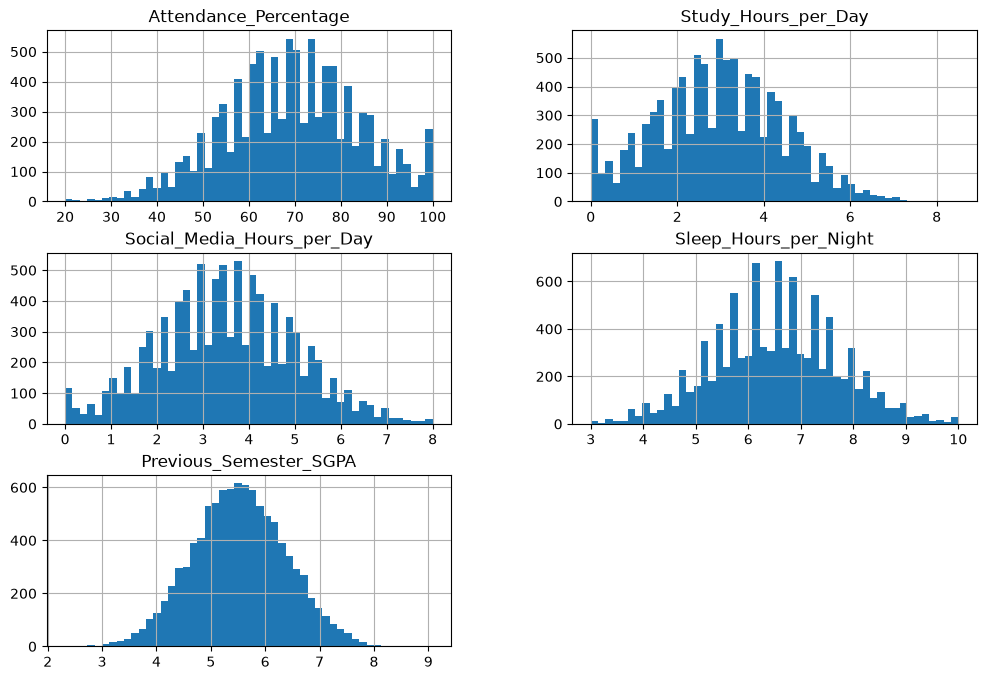

In [7]:
data.hist(bins=50, figsize=(12, 8))

In [8]:
data.dtypes

Attendance_Percentage           int64
Study_Hours_per_Day           float64
Social_Media_Hours_per_Day    float64
Sleep_Hours_per_Night         float64
Previous_Semester_SGPA        float64
Cleared_in_First_Attempt          str
dtype: object

In [9]:
data["Cleared_in_First_Attempt"] = data["Cleared_in_First_Attempt"].replace(
    {
        "Yes": True,
        "No": False
    }
).astype(bool)

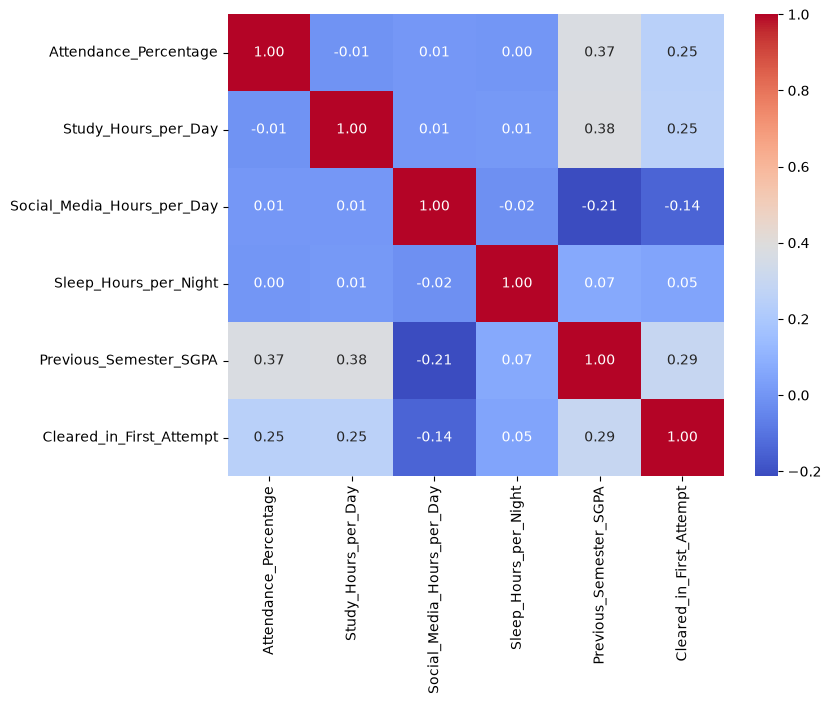

In [10]:
corr = data.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [11]:
Y = data["Cleared_in_First_Attempt"]
X = data.drop("Cleared_in_First_Attempt", axis=1)

In [12]:
X

,Attendance_Percentage,Study_Hours_per_Day,Social_Media_Hours_per_Day,Sleep_Hours_per_Night,Previous_Semester_SGPA
0,67,3.7,2.6,4.8,6.79
1,100,1.7,3.8,7.1,5.76
2,40,3.4,3.2,7.1,4.73
3,85,3.9,3.5,6.9,6.15
4,64,2.6,3.7,7.3,3.89
...,...,...,...,...,...
9995,76,3.5,3.3,6.7,5.38
9996,61,0.0,4.7,4.8,4.84
9997,83,2.6,0.9,6.5,6.13
9998,82,2.4,4.4,6.0,6.93


In [13]:
Y

0       False
1        True
2       False
3        True
4       False
        ...  
9995    False
9996    False
9997     True
9998     True
9999    False
Name: Cleared_in_First_Attempt, Length: 10000, dtype: bool

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
)

In [17]:
y_train.dtype

dtype('bool')

In [18]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")

imputer.fit(X_train)

X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression()

In [32]:
lg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [37]:
X_test

array([[ 0.39727071,  0.70893651,  1.43043154,  2.70737012,  1.22228131],
       [ 0.32890395,  1.67734849, -1.29702233,  1.59696315,  1.93442921],
       [-0.69659749,  2.29989905,  1.2258725 , -1.30717818,  0.04315118],
       ...,
       [-1.51699864,  0.84728108,  1.08949981, -1.64884186, -1.33444639],
       [ 1.1493051 , -0.39782004, -0.27422713, -0.70926673,  0.1715713 ],
       [-0.83333101, -0.25947547,  0.27126364, -0.79468265, -1.32277184]],
      shape=(2000, 5))

In [24]:
y_pred = lg.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.757

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[1380,  117],
       [ 369,  134]])

In [29]:
from sklearn.metrics import classification_report

classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n       False       0.79      0.92      0.85      1497\n        True       0.53      0.27      0.36       503\n\n    accuracy                           0.76      2000\n   macro avg       0.66      0.59      0.60      2000\nweighted avg       0.72      0.76      0.73      2000\n'

In [43]:
u = np.array([[67, 3.7, 2.6, 4.8, 6.79]])
t = lg.predict(u)

In [44]:
t

array([ True])

In [49]:
lg.coef_

array([[ 0.58093547,  0.55528071, -0.33296986,  0.08643263,  0.30680518]])